In [2]:
import pyodbc
import pandas as pd 
import matplotlib.pyplot as plt 
import plotly.express as px
import seaborn as sns
import numpy as np 
from sqlalchemy import create_engine

In [3]:
server = 'localhost, 1433'
database = 'TIMAU'
username= 'SA'
password = 'wUtang!#'

conn_str = f"mssql+pyodbc://{username}:{password}@{server}/{database}?driver=ODBC+Driver+18+for+SQL+Server&TrustServerCertificate=yes"

engine = create_engine(conn_str)
conn = engine.connect()

In [4]:
df = pd.read_sql_query("SELECT TOP 100* FROM OINV WHERE \"CANCELED\" = 'N'", conn)
df.head()


,DocEntry,DocNum,DocType,CANCELED,Handwrtten,Printed,DocStatus,InvntSttus,Transfered,ObjType,...,U_ModeTrns,U_Weight,U_ObjectId,U_ObjectType,U_ITEMGROUP,U_FiscalSaleType,U_FiscalSeal,U_CUIN,U_FiscalFooter,U_Type
0,1,1,S,N,N,Y,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
1,2,2,S,N,N,N,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
2,3,3,S,N,N,Y,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
3,4,4,S,N,N,N,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
4,5,5,S,N,N,N,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None


In [5]:
#drop all duplicates and ensure that only unique records are shown 
data =  df.drop_duplicates(subset=['DocEntry'], keep= 'first')
data.head()

,DocEntry,DocNum,DocType,CANCELED,Handwrtten,Printed,DocStatus,InvntSttus,Transfered,ObjType,...,U_ModeTrns,U_Weight,U_ObjectId,U_ObjectType,U_ITEMGROUP,U_FiscalSaleType,U_FiscalSeal,U_CUIN,U_FiscalFooter,U_Type
0,1,1,S,N,N,Y,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
1,2,2,S,N,N,N,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
2,3,3,S,N,N,Y,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
3,4,4,S,N,N,N,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None
4,5,5,S,N,N,N,C,C,N,13,...,None,None,None,None,None,None,None,None,None,None


In [6]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 455 entries, DocEntry to U_Type
dtypes: datetime64[us](5), float64(102), int64(40), object(202), str(106)
memory usage: 355.6+ KB


In [7]:
print(data[['CreateDate', 'CreateTS']].head())
print(data['CreateDate'].iloc[0])

  CreateDate  CreateTS
0 2013-04-27    105957
1 2013-04-27    111150
2 2013-04-27    112111
3 2013-04-27    113326
4 2013-04-27    113617
2013-04-27 00:00:00


In [8]:
print(data[['UpdateTS', 'UpdateDate']].head())

   UpdateTS UpdateDate
0    105958 2013-04-27
1    111150 2013-04-27
2    112112 2013-04-27
3    113326 2013-04-27
4    113617 2013-04-27


In [9]:
data['CreateDate'] = data['CreateDate'].astype(str) + ' ' + data['CreateTS'].astype(str)
data['CreateDate'] = pd.to_datetime(data['CreateDate'])
print(data['CreateDate'].head())

0   2013-04-27 10:59:57
1   2013-04-27 11:11:50
2   2013-04-27 11:21:11
3   2013-04-27 11:33:26
4   2013-04-27 11:36:17
Name: CreateDate, dtype: datetime64[us]


In [11]:
data['UpdateDate'] = data['UpdateDate'].astype(str) + ' ' + data['UpdateTS'].astype(str)
data['UpdateDate'] = pd.to_datetime(data['UpdateDate'])
print(data['UpdateDate'].head())

0   2013-04-27 10:59:58
1   2013-04-27 11:11:50
2   2013-04-27 11:21:12
3   2013-04-27 11:33:26
4   2013-04-27 11:36:17
Name: UpdateDate, dtype: datetime64[us]


## Univariate Analysis

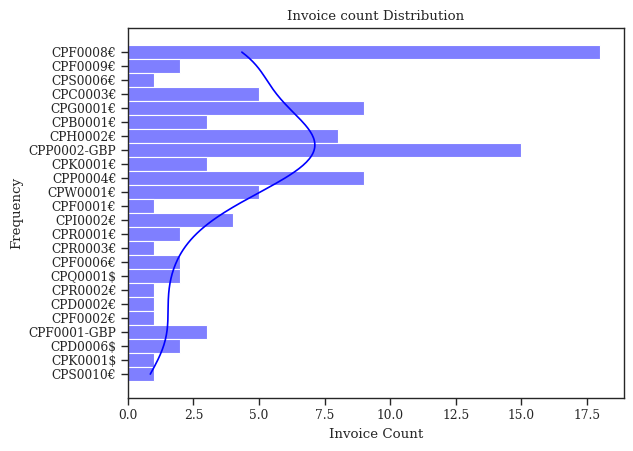

In [ ]:
# This is to show the data distribution ie invoice count

sns.set_theme(
    style = 'ticks', 
    context= 'paper',
    font = 'Serif' 
)
sns.histplot(
    data = data,
    y = 'CardCode',
    bins = 20,
    kde = True,
    color = 'blue')
plt.title('Invoice count Distribution')
plt.xlabel('Invoice Count')
plt.ylabel('Frequency')
plt.show()